# IBM HR Analytics - Employee Attrition Analysis

## Objective

Employee attrition is a major concern for organizations because replacing employees is costly and time-consuming.

The objective of this project is to identify the key drivers of employee attrition using Exploratory Data Analysis (EDA), feature engineering, statistical testing, and visualization.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


#### Findings
The dataset contains 1,470 employee records with 35 features.
There are a mix of numerical, categorical, and ordinal variables describing employee demographics, compensation, satisfaction, experience, and attrition.
The target variable is Attrition, indicating whether an employee has left the company.

### Basic Dataset Overview

In [3]:
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


#### Findings
-  The workforce is predominantly composed of early- and mid-career professionals.
-  Most employees live relatively close to the workplace, although a few employees have substantially longer commutes.
-  Employee salaries are not evenly distributed. A small proportion of senior employees earn significantly higher salaries than the majority of the workforce.
-  Only around 16% of employees have left the organization, indicating that the dataset is imbalanced. This should be considered when building predictive machine learning models.

In [6]:
df.describe(include='object').T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


### Data Analysis

In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Percentage": (df.isna().mean()*100).round(2)
})

missing

,Missing Values,Percentage
Age,0,0.0
Attrition,0,0.0
BusinessTravel,0,0.0
DailyRate,0,0.0
Department,0,0.0
DistanceFromHome,0,0.0
Education,0,0.0
EducationField,0,0.0
EmployeeCount,0,0.0
EmployeeNumber,0,0.0


#### The dataset is complete and does not require missing-value imputation, allowing the analysis to proceed without introducing bias from imputation techniques.

In [8]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicate employee records, indicating that each observation represents a unique employee.

In [9]:
pd.DataFrame(df.nunique(), columns=["Unique Values"]).sort_values("Unique Values")

,Unique Values
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


In [10]:
constant_col = [col for col in df.columns if df[col].nunique()==1]
constant_col

['EmployeeCount', 'Over18', 'StandardHours']

In [11]:
df.drop(columns=constant_col, inplace=True)

#### Dropped columns with a single unique value.

In [12]:
df['AttritionEncoded'] = df['Attrition'].map({'Yes':1,'No':0})
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionEncoded
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,4,1,6,3,3,2,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,...,3,1,17,3,3,5,2,0,3,0
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,...,1,1,9,5,3,7,7,1,7,0
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,...,2,1,6,0,3,6,2,0,3,0
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,...,4,0,17,3,2,9,6,0,8,0


### Univariate Analysis

In [13]:
numerical_col = df.select_dtypes(include=np.number).columns
numerical_col

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'AttritionEncoded'],
      dtype='object')

In [14]:
summary = df[numerical_col].agg([
    'mean',
    'median',
    'std',
    'min',
    'max',
    'skew',
    'kurt'
]).T

summary

,mean,median,std,min,max,skew,kurt
Age,36.923810,36.0,9.135373,18.0,60.0,0.413286,-0.404145
DailyRate,802.485714,802.0,403.509100,102.0,1499.0,-0.003519,-1.203823
DistanceFromHome,9.192517,7.0,8.106864,1.0,29.0,0.958118,-0.224833
Education,2.912925,3.0,1.024165,1.0,5.0,-0.289681,-0.559115
EmployeeNumber,1024.865306,1020.5,602.024335,1.0,2068.0,0.016574,-1.223179
EnvironmentSatisfaction,2.721769,3.0,1.093082,1.0,4.0,-0.321654,-1.202521
HourlyRate,65.891156,66.0,20.329428,30.0,100.0,-0.032311,-1.196398
JobInvolvement,2.729932,3.0,0.711561,1.0,4.0,-0.498419,0.270999
JobLevel,2.063946,2.0,1.106940,1.0,5.0,1.025401,0.399152
JobSatisfaction,2.728571,3.0,1.102846,1.0,4.0,-0.329672,-1.222193


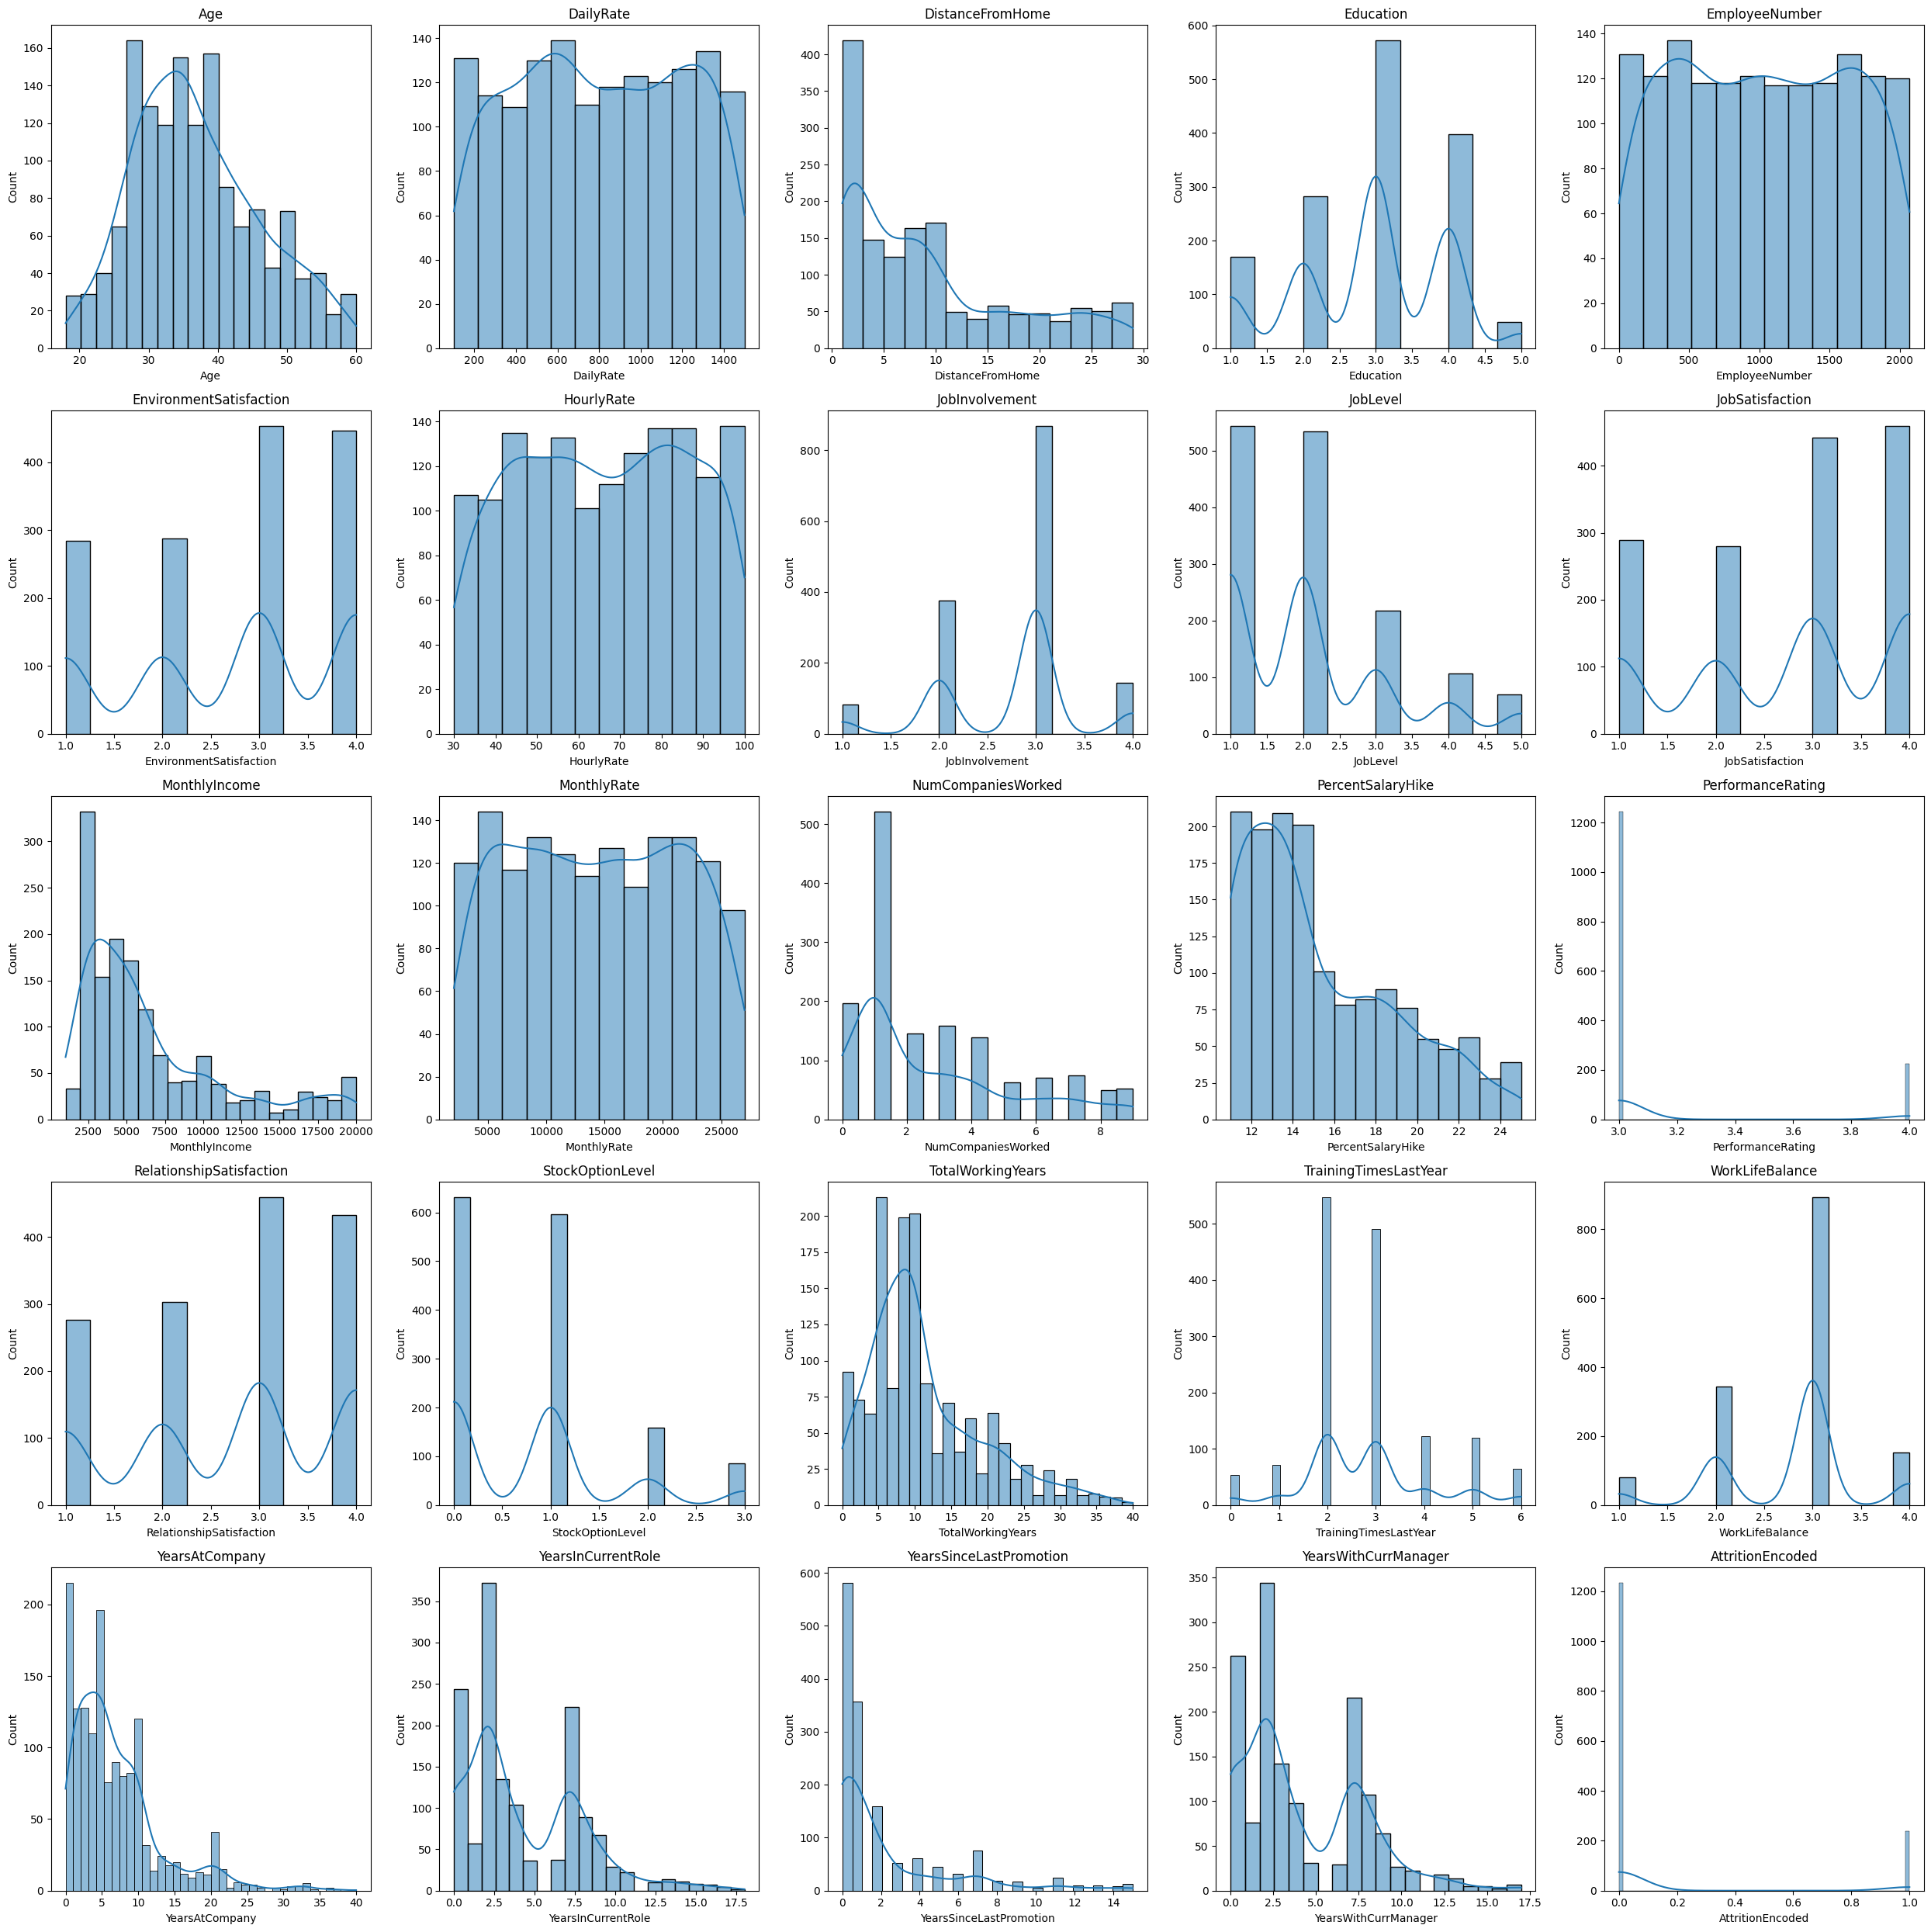

In [15]:
plt.figure(figsize=(25,25))
for i,col in enumerate(numerical_col):
    plt.subplot(5,5,i+1)
    sns.histplot(df[col],
                 kde=True)

    plt.title(col)

plt.tight_layout()
plt.show()

#### Findings
-  The workforce primarily consists of early- and mid-career professionals.
-  Employee salaries are unevenly distributed, with a relatively small number of highly compensated senior employees.
-  Most employees possess fewer than 15 years of total work experience, with only a small proportion having extensive careers.
-  The organization has a large proportion of relatively new employees and comparatively fewer long-tenured employees.
-  Promotions appear to occur relatively early in employees' careers, while long delays between promotions are less common.
-  Most employees live close to their workplace, although a smaller group commutes significantly farther.
-  The workforce is predominantly composed of junior and mid-level employees, with comparatively fewer senior-level employees.
-  Overall job satisfaction is relatively positive across the organization, though dissatisfied employees remain an important focus for retention efforts.
-  Employees generally report favorable workplace environments, indicating that other factors may play a larger role in attrition.
-  Employees generally perceive their work-life balance as good rather than poor or excellent.

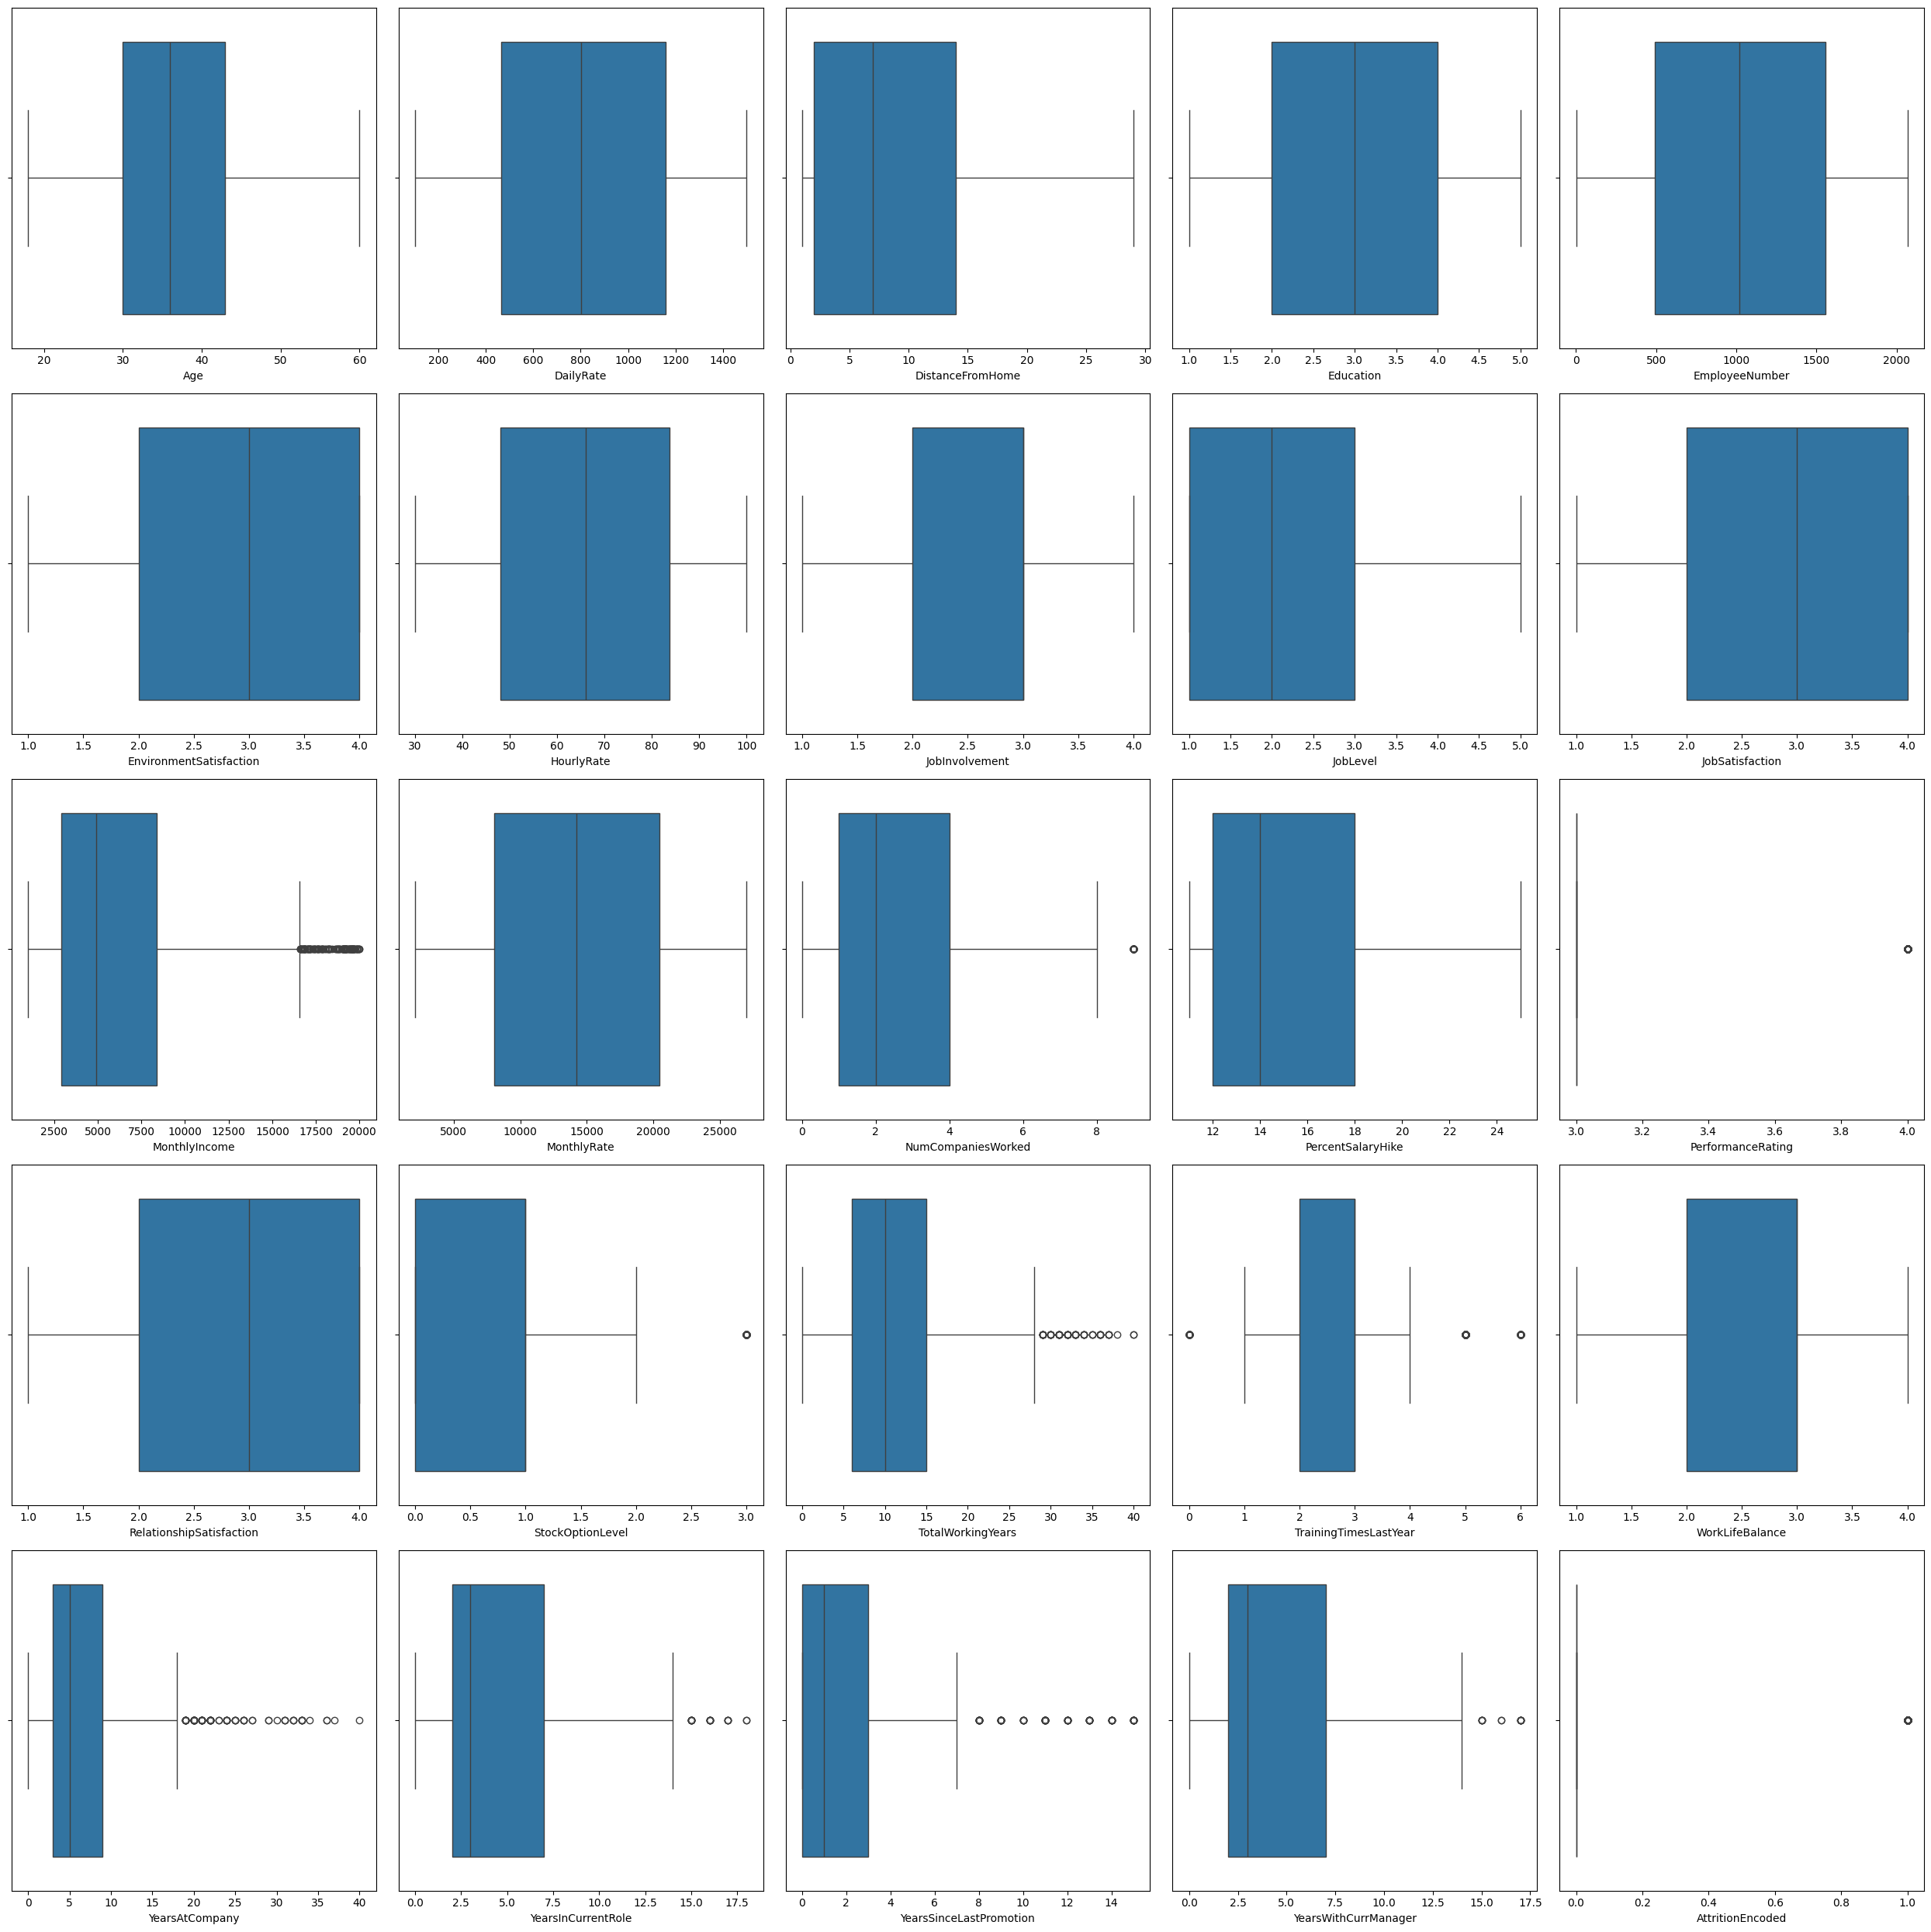

In [16]:
plt.figure(figsize=(25,25))
for i,col in enumerate(numerical_col):

    plt.subplot(5,5,i+1)

    sns.boxplot(x=df[col])

plt.tight_layout()
plt.show()

#### The observed outliers are likely genuine employees occupying senior positions rather than data entry errors. Therefore, they should be retained for business analysis.

In [17]:
categorical_col = df.select_dtypes(include='object').columns
categorical_col

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

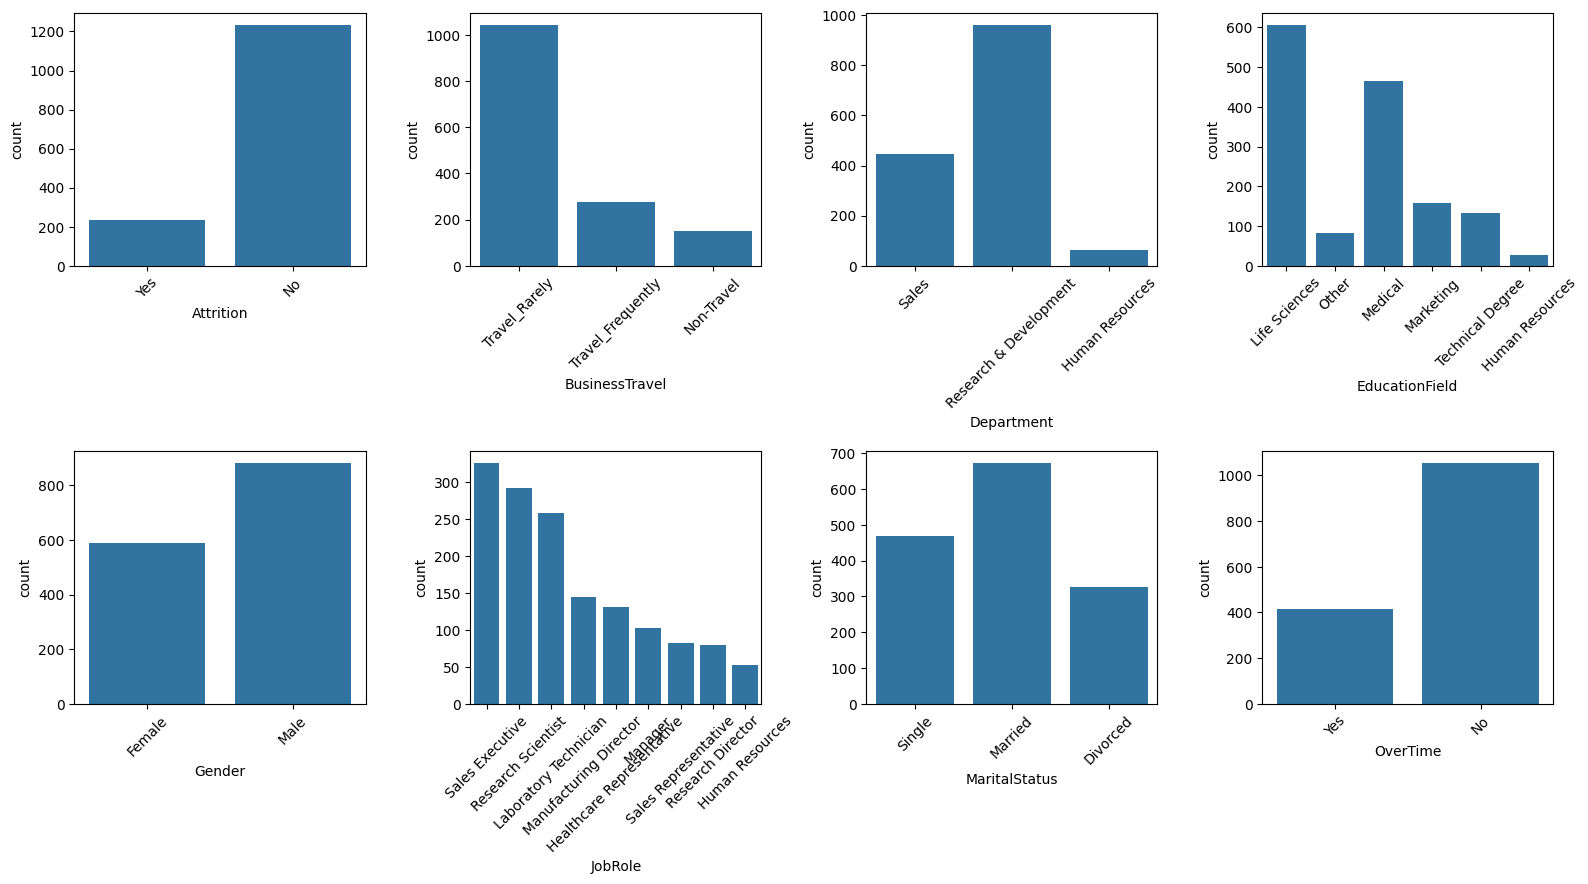

In [18]:
plt.figure(figsize=(16,16))
for i,col in enumerate(categorical_col):

    plt.subplot(4,4,i+1)
    sns.countplot(data=df,x=col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Findings
-  Research & Development forms the core business function, accounting for the majority of employees.
-  The organization primarily consists of employees who travel infrequently for work.
-  The workforce is moderately male-dominated.
-  Employees from Life Sciences represent the largest educational background, reflecting the technical nature of the organization.

In [19]:
attrition = df["Attrition"].value_counts()

attrition

Attrition
No     1233
Yes     237
Name: count, dtype: int64

<Axes: ylabel='count'>

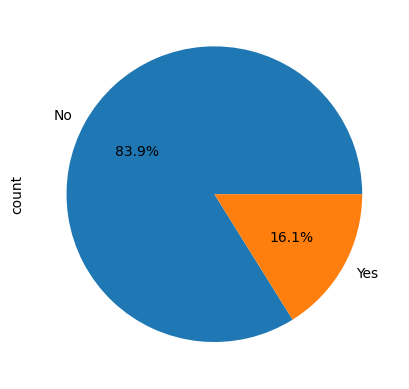

In [20]:
df["Attrition"].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

### Bivariate Analysis

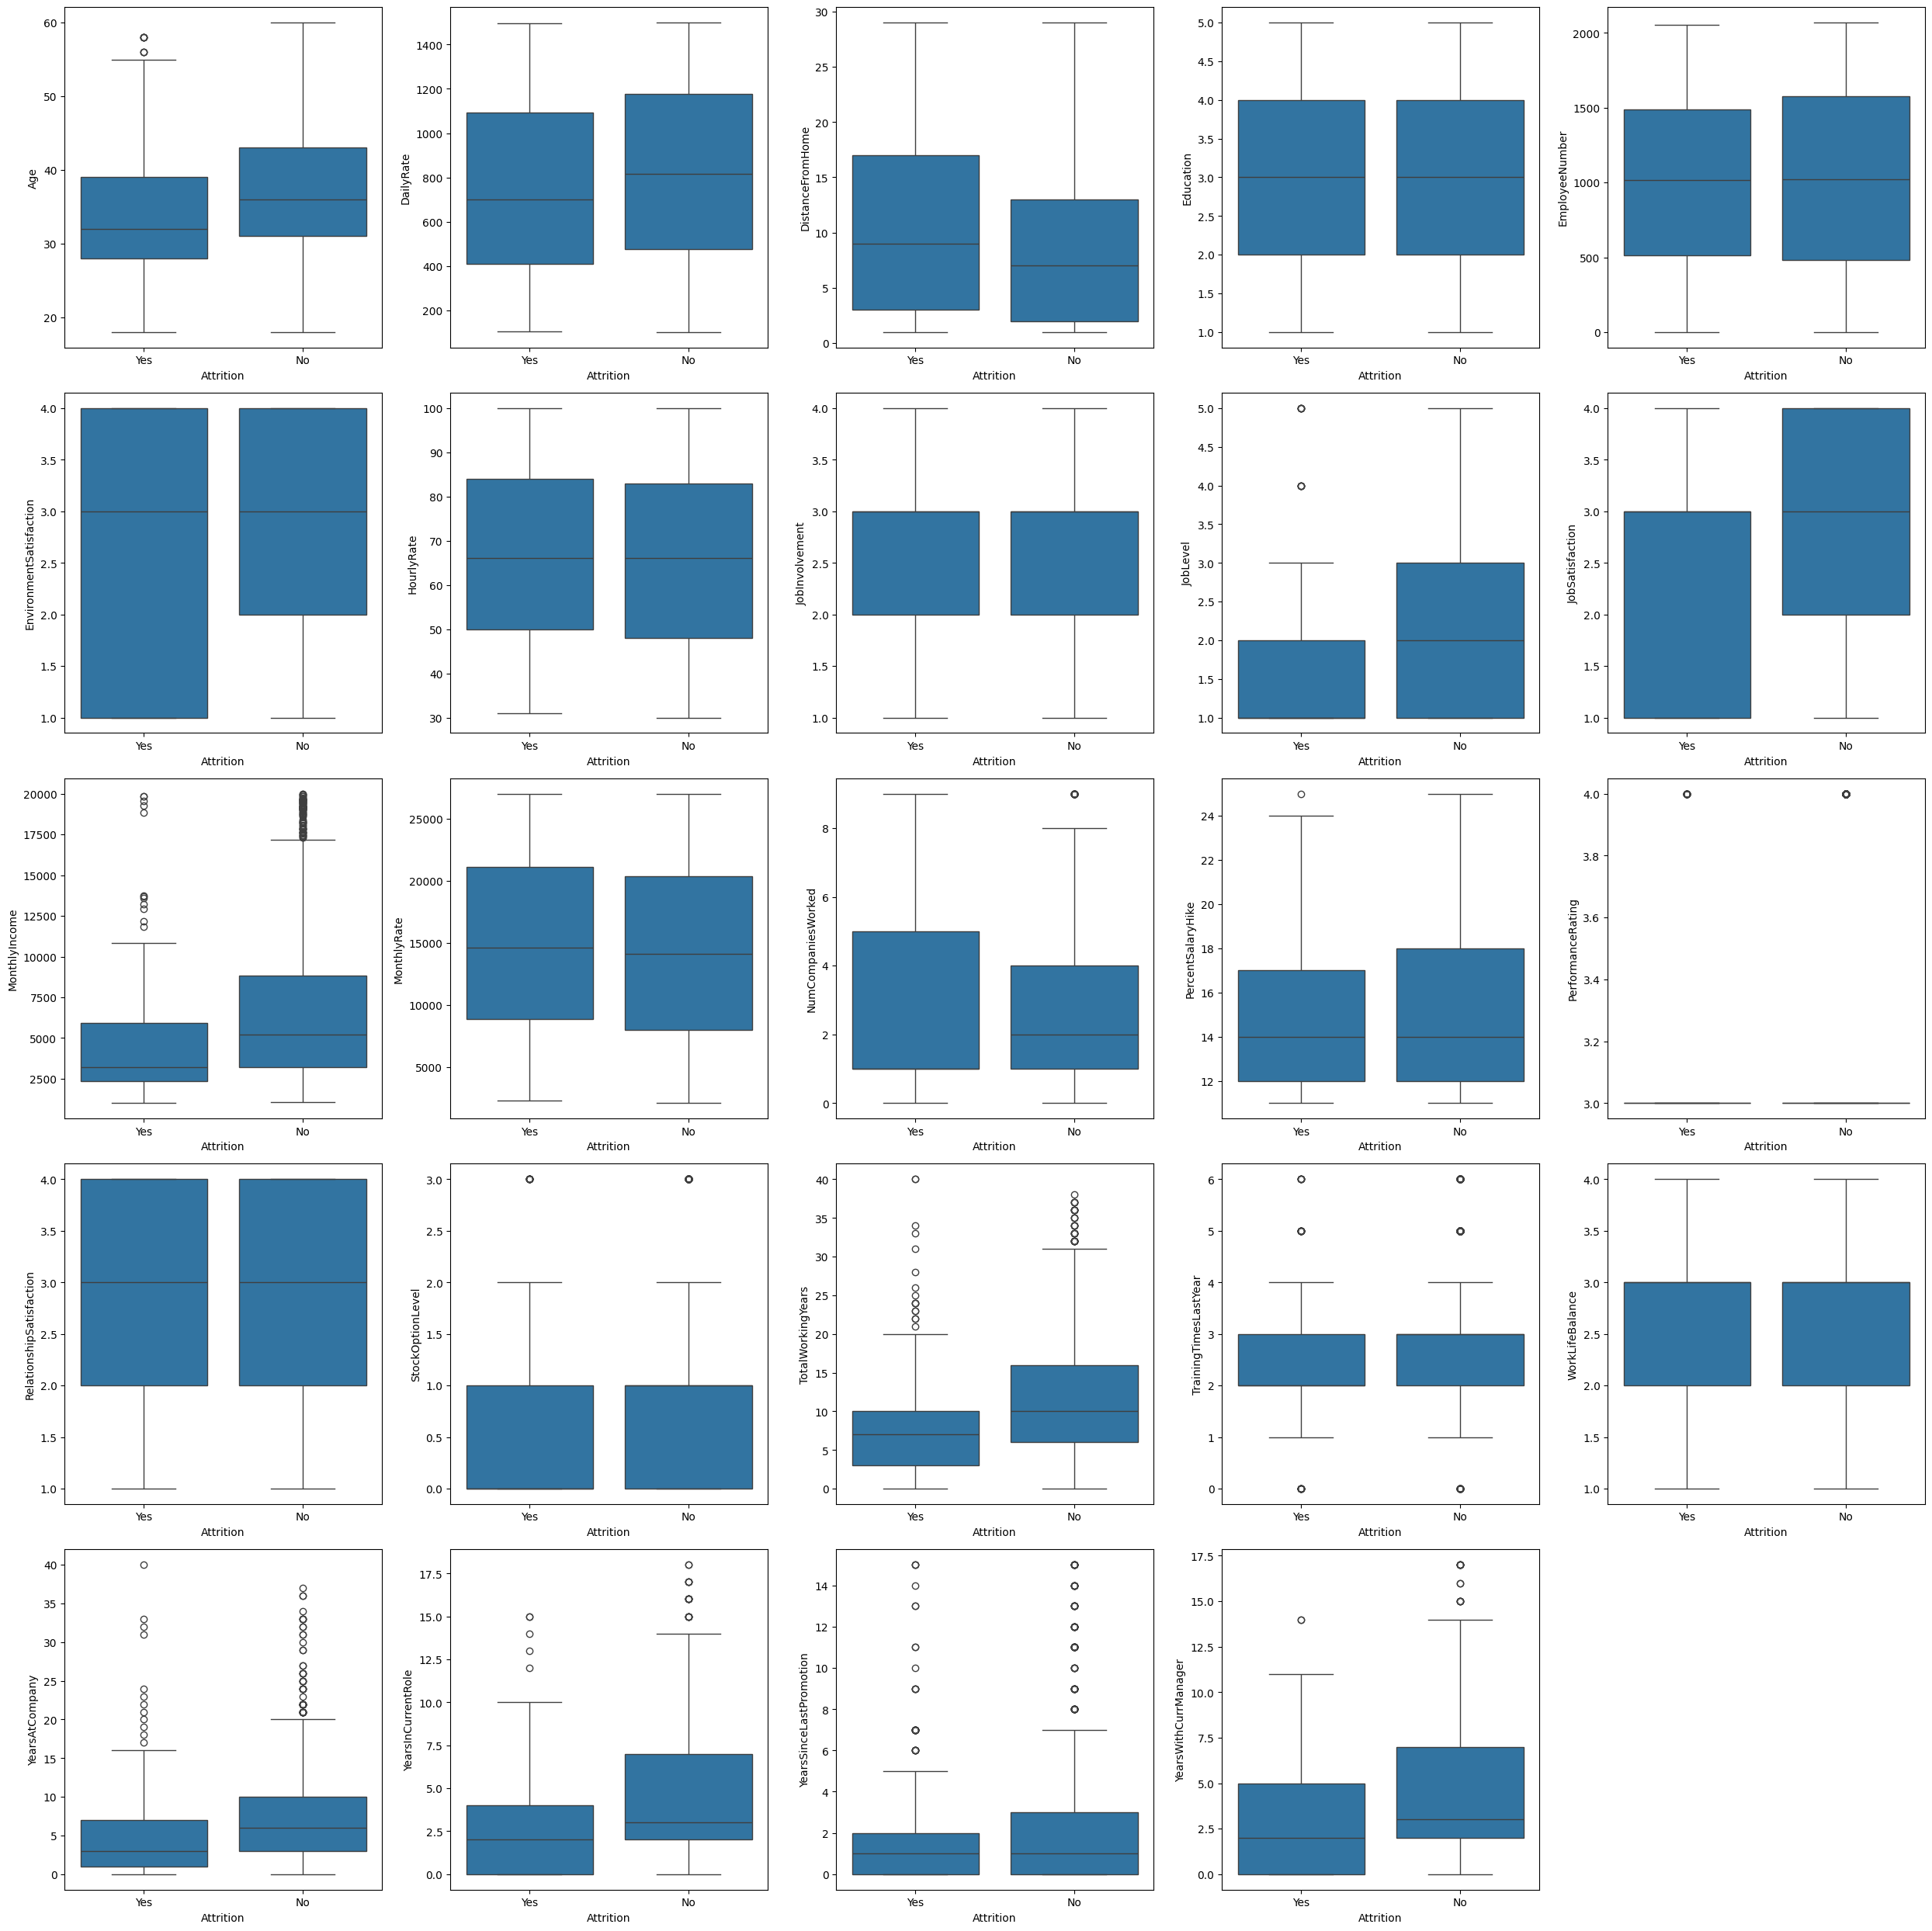

In [21]:
plt.figure(figsize=(25,25))
for i,col in enumerate(numerical_col):

    if col!="AttritionEncoded":
        plt.subplot(5,5,i+1)
        sns.boxplot(data=df,
                    x="Attrition",
                    y=col)
plt.tight_layout()
plt.show()

#### Findings
-  Younger employees appear more likely to leave the organization, while older employees tend to remain longer.
-  Daily pay rate does not appear to meaningfully differentiate employees who leave from those who stay.
-  Longer commuting distances may contribute to employee turnover, although the relationship appears modest.
-  Educational qualification does not appear to significantly influence employee retention.
-  Employees who are more engaged in their work appear less likely to leave the organization.
-  Attrition appears to be higher among entry-level employees, whereas employees in senior positions demonstrate greater organizational stability.
-  Lower-paid employees appear more likely to leave.
-  Annual salary increases do not appear to substantially influence employee attrition.
-  More experienced employees appear less likely to leave the organization.

#### Feature Engineering

In [22]:
bins = [18,25,35,45,55,65]
labels = [
    "Early Career",
    "Developing Professional",
    "Mid Career",
    "Senior Professional",
    "Late Career"
]

df['AgeGroup'] = pd.cut(
    x=df['Age'],
    bins=bins,
    labels=labels
)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionEncoded,AgeGroup
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,0,8,0,1,6,4,0,5,1,Mid Career
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,1,10,3,3,10,7,1,7,0,Senior Professional
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,0,7,3,3,0,0,0,0,1,Mid Career
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,0,8,3,3,8,7,3,0,0,Developing Professional
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,1,6,3,3,2,2,2,2,0,Developing Professional


In [23]:
bins = [0,2,5,10,20,40]
labels = ["0-2","3-5","6-10","11-20","20+"]

df['YearsOfExperience'] = pd.cut(x=df['YearsAtCompany'],bins=bins,labels=labels)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionEncoded,AgeGroup,YearsOfExperience
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,8,0,1,6,4,0,5,1,Mid Career,6-10
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,10,3,3,10,7,1,7,0,Senior Professional,6-10
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,7,3,3,0,0,0,0,1,Mid Career,NaN
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,8,3,3,8,7,3,0,0,Developing Professional,6-10
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,6,3,3,2,2,2,2,0,Developing Professional,0-2


In [24]:
df['YearsOfExperience'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1470 entries, 0 to 1469
Series name: YearsOfExperience
Non-Null Count  Dtype   
--------------  -----   
1426 non-null   category
dtypes: category(1)
memory usage: 1.8 KB


In [25]:
df['YearsOfExperience'].fillna("0-2",inplace=True)

df['YearsOfExperience'].value_counts()

C:\Users\pkaus\AppData\Local\Temp\ipykernel_5864\3378278814.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['YearsOfExperience'].fillna("0-2",inplace=True)


YearsOfExperience
6-10     448
3-5      434
0-2      342
11-20    180
20+       66
Name: count, dtype: int64

In [26]:
df["IncomeBand"] = pd.qcut(
    df["MonthlyIncome"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Executive"
    ]
)

df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionEncoded,AgeGroup,YearsOfExperience,IncomeBand
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,0,1,6,4,0,5,1,Mid Career,6-10,High
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,3,3,10,7,1,7,0,Senior Professional,6-10,High
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,3,0,0,0,0,1,Mid Career,0-2,Low
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,8,7,3,0,0,Developing Professional,6-10,Low
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,3,2,2,2,2,0,Developing Professional,0-2,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,...,3,3,5,2,0,3,0,Mid Career,3-5,Low
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,...,5,3,7,7,1,7,0,Mid Career,6-10,Executive
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,...,0,3,6,2,0,3,0,Developing Professional,6-10,High
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,...,3,2,9,6,0,8,0,Senior Professional,6-10,High


In [27]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionEncoded,AgeGroup,YearsOfExperience,IncomeBand
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,0,1,6,4,0,5,1,Mid Career,6-10,High
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,3,3,10,7,1,7,0,Senior Professional,6-10,High
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,3,0,0,0,0,1,Mid Career,0-2,Low
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,8,7,3,0,0,Developing Professional,6-10,Low
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,3,2,2,2,2,0,Developing Professional,0-2,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,3,...,3,3,5,2,0,3,0,Mid Career,3-5,Low
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,4,...,5,3,7,7,1,7,0,Mid Career,6-10,Executive
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,2,...,0,3,6,2,0,3,0,Developing Professional,6-10,High
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,4,...,3,2,9,6,0,8,0,Senior Professional,6-10,High


### Attrition Rate by Category

In [44]:
def attrition_rate(column):

    return (
        df.groupby(column)["AttritionEncoded"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

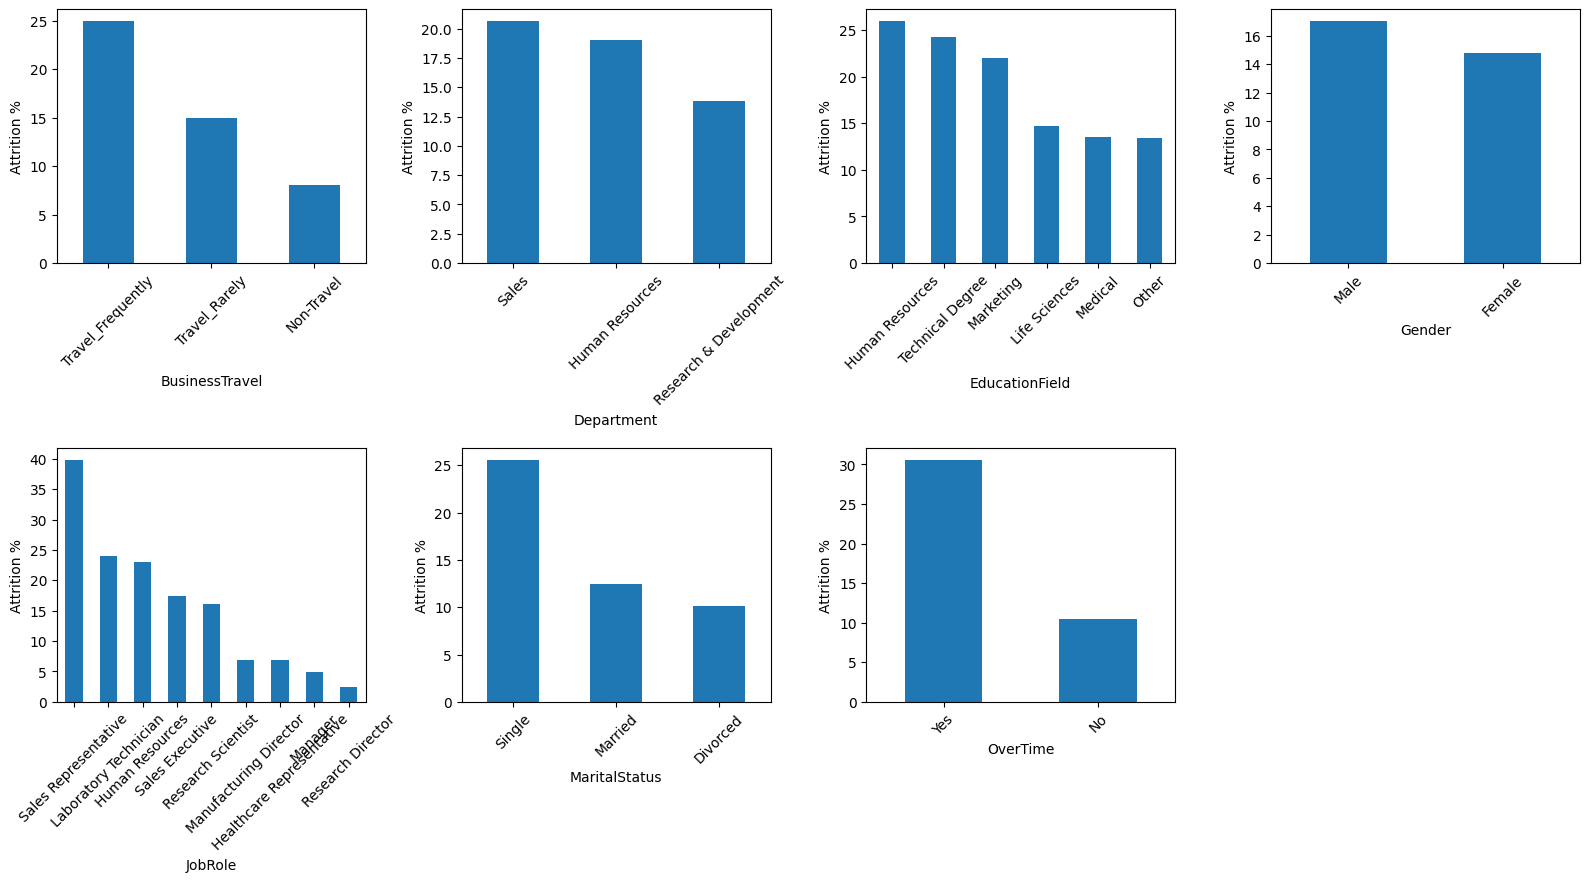

In [38]:
plt.figure(figsize=(16,16))
for i,col in enumerate(categorical_col):
    if col != 'Attrition':
        plt.subplot(4,4,i)
        rate=attrition_rate(col)
        rate.plot.bar()
        plt.xticks(rotation=45)
        plt.ylabel("Attrition %")

plt.tight_layout()
plt.show()

#### Correlation Analysis

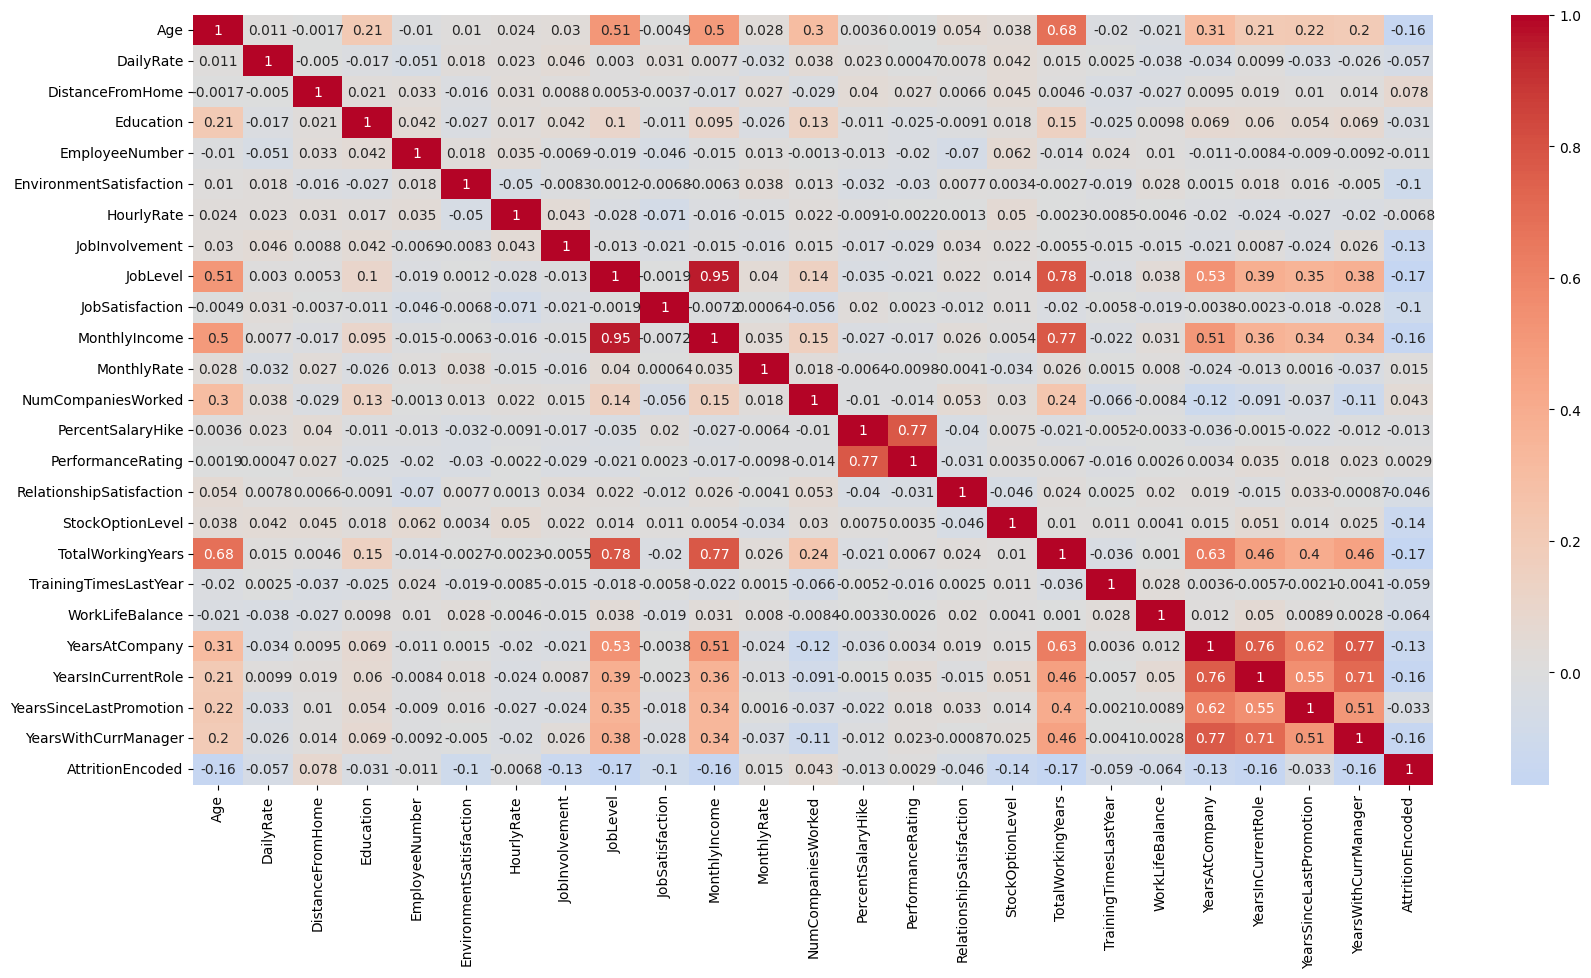

In [39]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(20,10))
sns.heatmap(corr,cmap='coolwarm',annot=True,center=0)
plt.show()

#### Although the correlations are relatively weak, they consistently indicate that employees who are older, more experienced, higher paid, and have longer tenure are less likely to leave the organization.

C:\Users\pkaus\AppData\Local\Temp\ipykernel_5864\231156316.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_corr.values, y=attrition_corr.index, palette='coolwarm')


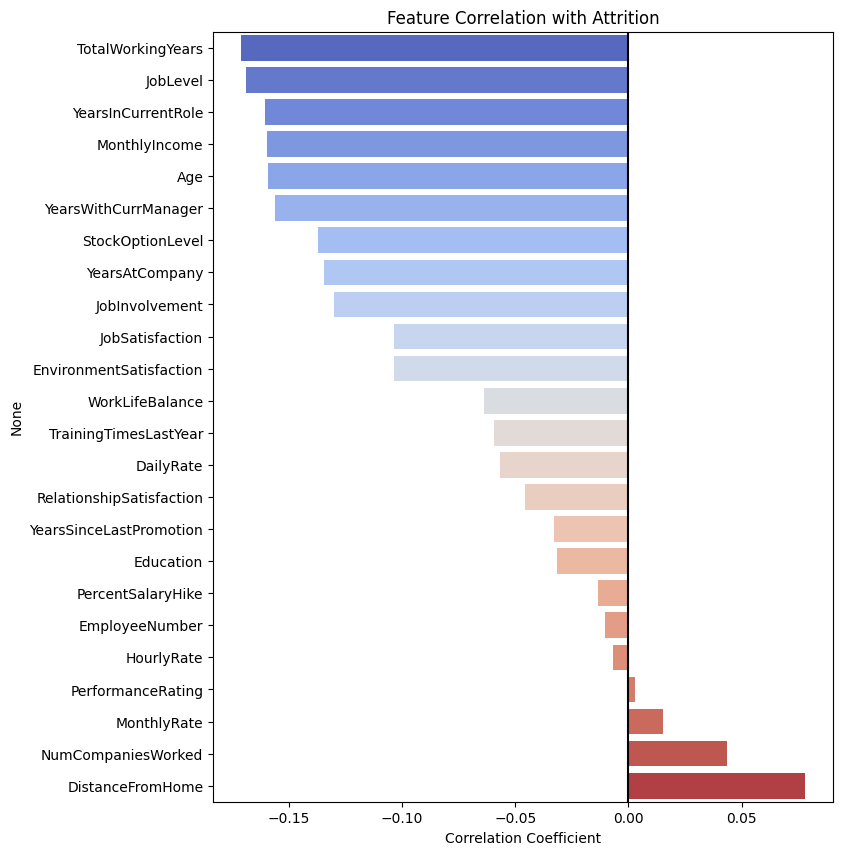

In [43]:
# Compute correlation of everything against the target
attrition_corr = df.corr(numeric_only=True)['AttritionEncoded'].sort_values()

# Drop the self-correlation row
attrition_corr = attrition_corr.drop('AttritionEncoded')

# Plot the ranking
plt.figure(figsize=(8, 10))
sns.barplot(x=attrition_corr.values, y=attrition_corr.index, palette='coolwarm')
plt.title('Feature Correlation with Attrition')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-')
plt.show()


#### Attrition Rate Summary

In [41]:
def attrition_summary(column):
    return (
        df.groupby(column)
          .agg(
              Employees=("Attrition", "count"),
              Employees_Left=("AttritionEncoded", "sum"),
              Attrition_Rate=("AttritionEncoded", "mean")
          )
          .assign(Attrition_Rate=lambda x: (x["Attrition_Rate"] * 100).round(2))
          .sort_values("Attrition_Rate", ascending=False)
    )

In [42]:
attrition_summary("OverTime")

,Employees,Employees_Left,Attrition_Rate
OverTime,,,
Yes,416,127,30.53
No,1054,110,10.44
